# Análisis de validación — Dynare Translate / Bootcamp DSGE
**Encuesta a estudiantes de macroeconomía de la Universidad del Pacífico (UP)**

Este cuaderno analiza las respuestas de la encuesta de validación del problema
para el proyecto *Dynare Translate*. Objetivo: cuantificar el dolor, segmentar al
cliente y medir la demanda — evidencia para la sección **Problema & validación**
del pitch.

> **Privacidad:** la encuesta capturó el correo institucional solo para
> deduplicar. Aquí se trabaja de forma **agregada y anónima**: la columna de
> correo no se usa ni se muestra.

> **Nota metodológica (limitación):** por un fallo de ruteo del formulario, las
> preguntas de *uso y disposición a pagar del segmento que YA usa Dynare* solo
> capturaron 1 respuesta. La demanda se mide con el bloque de no-usuarios
> (n=43) y con el bloque de "qué haces hoy". Se documenta como mejora para una v2.


In [1]:
# Configuración
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Estilo sobrio para el deck
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "figure.autolayout": True,
})
ACCENT = "#3b5b92"   # azul sobrio
ACCENT2 = "#9bb0d4"

FIG_DIR = Path("figuras"); FIG_DIR.mkdir(exist_ok=True)
def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    return fig


In [2]:
# Carga de datos
candidates = [Path("data/Dynare — Macro UP.csv"),
              Path("docs/research/data/Dynare — Macro UP.csv")]
CSV = next((p for p in candidates if p.exists()), candidates[0])
df = pd.read_csv(CSV)

# Renombrar a códigos cortos (el orden corresponde al diseño de la encuesta)
cols = list(df.columns)
codes = ["ts","email","edad","sexo","carrera","ingreso","cursos","herramientas",
         "nivel","replicar","horas","frustracion","obstaculos","quehaces",
         "uso_ia","ia_freq","ia_catch","u_usaria","u_pagaria",
         "nu_interes","nu_barreras","nu_usaria"]
df.columns = codes
df = df.drop(columns=["email"])          # anonimizar: descartamos el correo
print("Respuestas:", len(df))
df.head(3)


Respuestas: 59


,ts,edad,sexo,carrera,ingreso,cursos,herramientas,nivel,replicar,horas,...,obstaculos,quehaces,uso_ia,ia_freq,ia_catch,u_usaria,u_pagaria,nu_interes,nu_barreras,nu_usaria
0,2026/06/20 4:48:50 p.m. GMT-5,24,Masculino,Economía,2021-II,Economía General II;Macroeconomía I;Macroecono...,Excel;R;Stata,Nunca lo he usado,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Definitivamente sí,No sé por dónde empezar,Definitivamente sí
1,2026/06/20 4:49:11 p.m. GMT-5,20,Femenino,Economía,2023-II,Economía General II;Macroeconomía I;Macroecono...,Excel;Python;R,Nunca lo he usado,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Definitivamente sí,No sé por dónde empezar,Definitivamente sí
2,2026/06/20 4:49:32 p.m. GMT-5,20,Masculino,Finanzas,2023-I,Economía General II,Excel;Python;R;Stata,Nunca lo he usado,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Definitivamente sí,Me parece muy difícil;No tengo tiempo,Definitivamente sí


In [3]:
# Helper para preguntas de selección múltiple (valores separados por ';')
def multiselect_counts(series):
    s = series.dropna().astype(str)
    items = s.str.split(";").explode().str.strip()
    return items.value_counts()

def hbar(counts, title, fname, color=ACCENT, pct_base=None):
    fig, ax = plt.subplots(figsize=(7.2, 0.55*len(counts)+1.2))
    counts = counts.sort_values()
    ax.barh(counts.index, counts.values, color=color)
    base = pct_base or counts.sum()
    for i,(v) in enumerate(counts.values):
        ax.text(v+0.1, i, f" {v}", va="center", fontsize=10)
    ax.set_title(title, fontsize=12, loc="left", pad=10)
    ax.set_xlabel("respuestas")
    save(fig, fname); plt.show()


## 1. Perfil de la muestra

Edad — describe:
count    59.0
mean     21.1
min      18.0
max      40.0
Name: edad, dtype: float64

Sexo:
 sexo
Masculino            40
Femenino             15
Otro                  3
Prefiero no decir     1


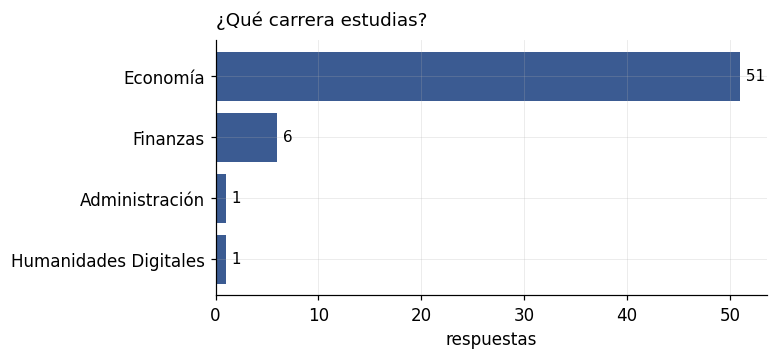

In [4]:
print("Edad — describe:")
print(pd.to_numeric(df.edad, errors='coerce').describe()[["count","mean","min","max"]].round(1))
print("\nSexo:\n", df.sexo.value_counts().to_string())

# Carrera
hbar(df.carrera.value_counts(), "¿Qué carrera estudias?", "perfil_carrera")


Años aprox. en la UP — media: 3.7 | mediana: 3.5


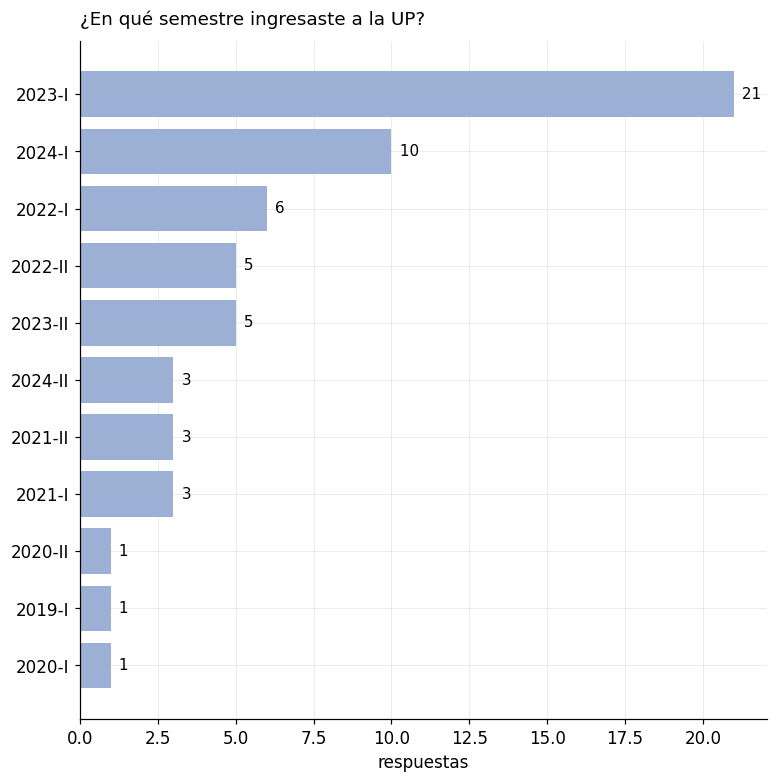

In [5]:
# Años aproximados en la UP a partir del semestre de ingreso
def ingreso_to_year(x):
    if pd.isna(x): return np.nan
    x = str(x)
    if "Antes" in x: return 2017.0
    try:
        y, sem = x.split("-")
        return float(y) + (0.0 if sem.strip()=="I" else 0.5)
    except Exception:
        return np.nan
anio_ing = df.ingreso.map(ingreso_to_year)
anios_en_up = (2026.5 - anio_ing)   # 2026-I ~ mediados de 2026
print("Años aprox. en la UP — media:", round(anios_en_up.mean(),1),
      "| mediana:", round(anios_en_up.median(),1))
hbar(df.ingreso.value_counts(), "¿En qué semestre ingresaste a la UP?", "perfil_ingreso", color=ACCENT2)


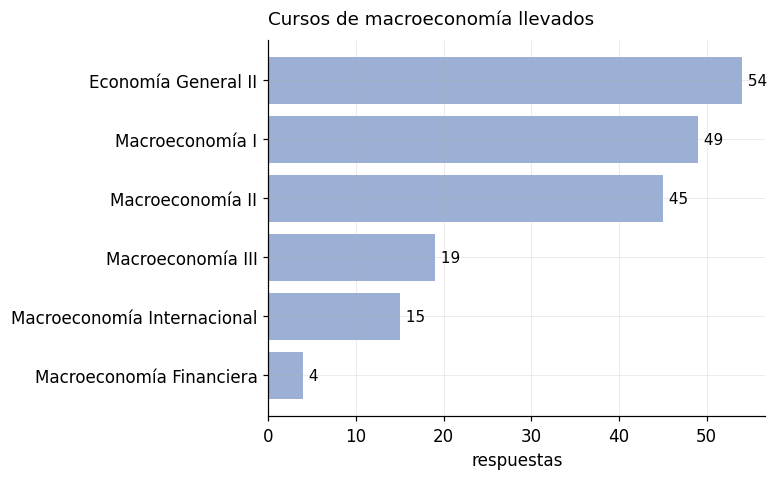

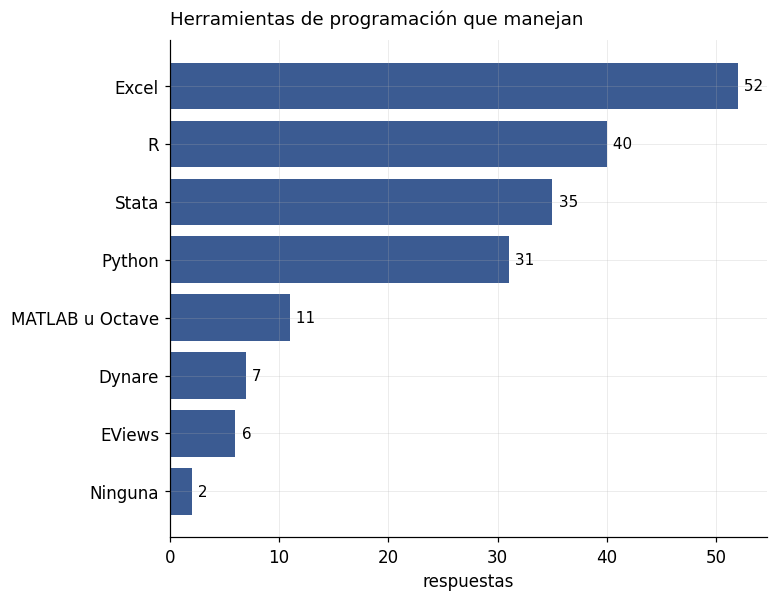

In [6]:
# Cursos de macro y herramientas (selección múltiple)
hbar(multiselect_counts(df.cursos), "Cursos de macroeconomía llevados", "perfil_cursos", color=ACCENT2)
hbar(multiselect_counts(df.herramientas), "Herramientas de programación que manejan", "perfil_herramientas")


## 2. Segmentación: ¿quién ha tocado Dynare?

La pregunta clave de segmentación es el **nivel con Dynare**.

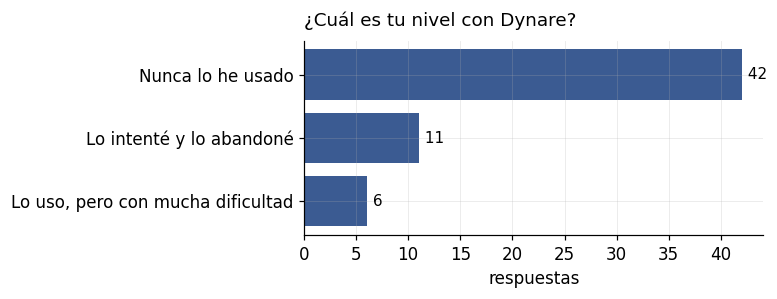

Nunca han usado Dynare: 42/59 = 71%
Tienen alguna experiencia: 17/59 = 29%


In [7]:
nivel = df.nivel.value_counts()
hbar(nivel, "¿Cuál es tu nivel con Dynare?", "seg_nivel")

n = len(df)
nunca = int((df.nivel == "Nunca lo he usado").sum())
usuarios = n - nunca
print(f"Nunca han usado Dynare: {nunca}/{n} = {nunca/n:.0%}")
print(f"Tienen alguna experiencia: {usuarios}/{n} = {usuarios/n:.0%}")


## 3. El dolor (segmento con experiencia en Dynare)

Filtramos a quienes ingresaron al bloque de experiencia (n≈17).

Tamaño del segmento con experiencia: 17
Frustración media: 3.47 / 5   (mediana: 4.0 )


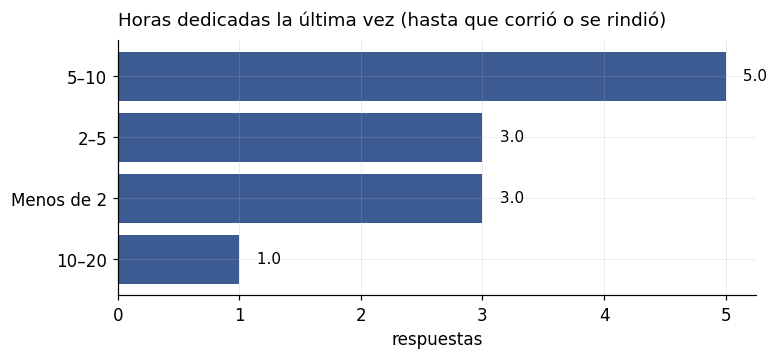

In [8]:
dolor = df[df.replicar.notna()].copy()
print("Tamaño del segmento con experiencia:", len(dolor))

# Frustración (escala 1-5)
fr = pd.to_numeric(dolor.frustracion, errors='coerce')
print("Frustración media:", round(fr.mean(),2), "/ 5   (mediana:", fr.median(), ")")

# Horas invertidas la última vez
orden_h = ["Menos de 2","2–5","5–10","10–20","Más de 20"]
hh = dolor.horas.value_counts().reindex(orden_h).dropna()
hbar(hh, "Horas dedicadas la última vez (hasta que corrió o se rindió)", "dolor_horas")


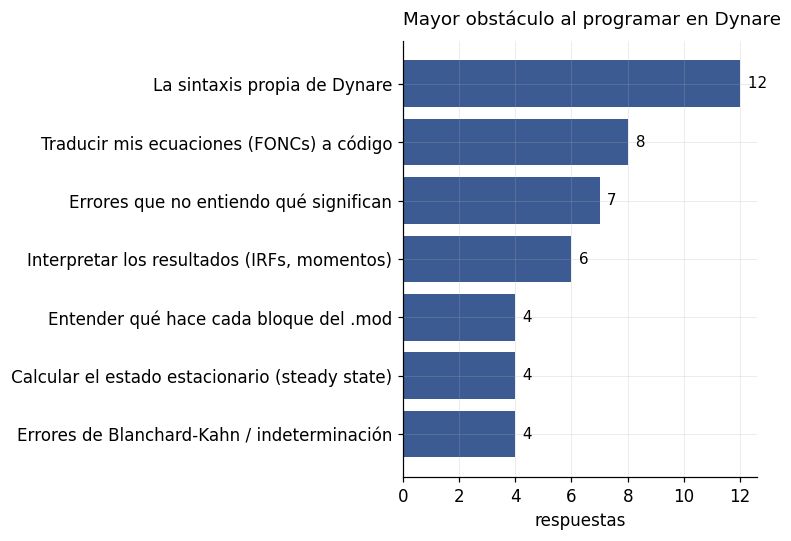

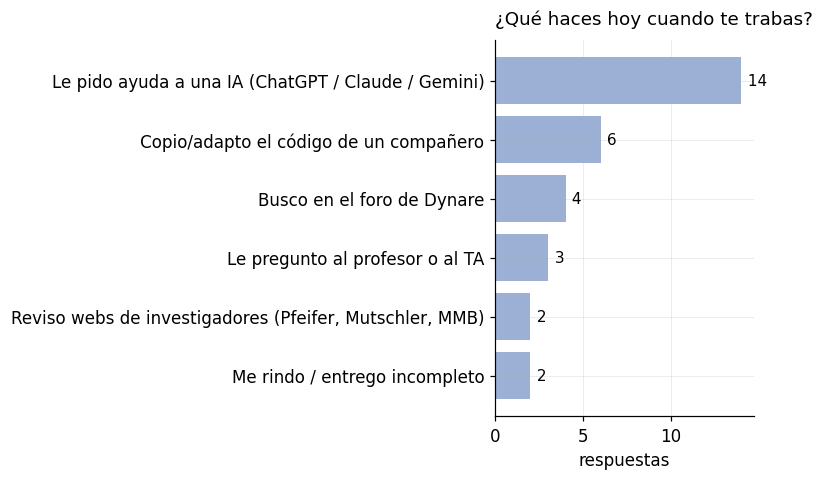

In [9]:
# Obstáculos (selección múltiple)
hbar(multiselect_counts(dolor.obstaculos), "Mayor obstáculo al programar en Dynare",
     "dolor_obstaculos")
# Qué hacen hoy cuando se traban
hbar(multiselect_counts(dolor.quehaces), "¿Qué haces hoy cuando te trabas?",
     "dolor_quehaces", color=ACCENT2)


## 4. El insight: la IA se equivoca y el alumno no se da cuenta

Este es el corazón del *why now* del pitch.

Usaron IA para Dynare (entre los que respondieron el bloque): 14


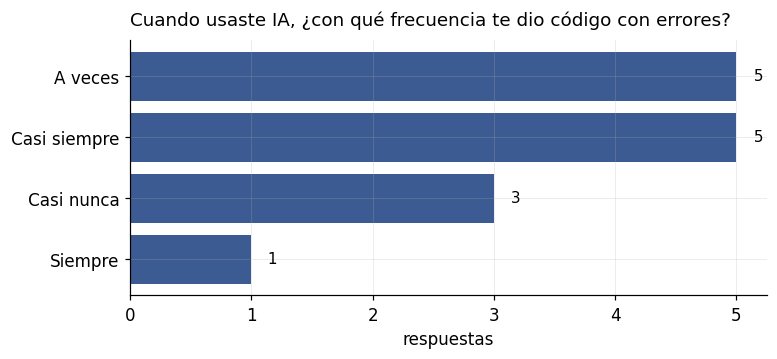

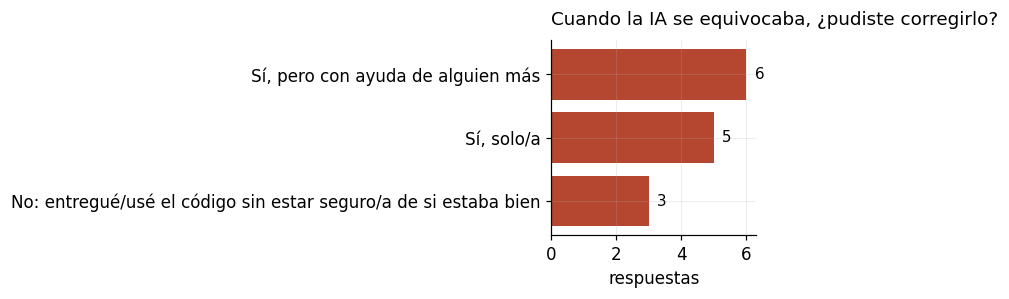


No pudieron verificar solos (sin ayuda o sin saber): 9/14 = 64%
  - Usaron el código sin saber si estaba bien: 3/14


In [10]:
ia = df[df.ia_freq.notna()].copy()
print("Usaron IA para Dynare (entre los que respondieron el bloque):", len(ia))

# Frecuencia de errores
orden_f = ["Siempre","Casi siempre","A veces","Casi nunca"]
ff = ia.ia_freq.value_counts().reindex(orden_f).dropna()
hbar(ff, "Cuando usaste IA, ¿con qué frecuencia te dio código con errores?",
     "ia_frecuencia")

# ¿Pudo darse cuenta y corregir?
cc = ia.ia_catch.value_counts()
hbar(cc, "Cuando la IA se equivocaba, ¿pudiste corregirlo?", "ia_corregir", color="#b5462f")

no_verif = ia.ia_catch.str.startswith("No").sum()
con_ayuda = ia.ia_catch.str.contains("con ayuda").sum()
print(f"\nNo pudieron verificar solos (sin ayuda o sin saber): "
      f"{no_verif+con_ayuda}/{len(ia)} = {(no_verif+con_ayuda)/len(ia):.0%}")
print(f"  - Usaron el código sin saber si estaba bien: {no_verif}/{len(ia)}")


## 5. Demanda y mercado (segmento que aún no programa) — TAM

71% nunca ha usado Dynare. Aquí medimos su predisposición: este es el mercado
latente que el bootcamp puede activar.

Segmento no-usuarios que respondió: 43


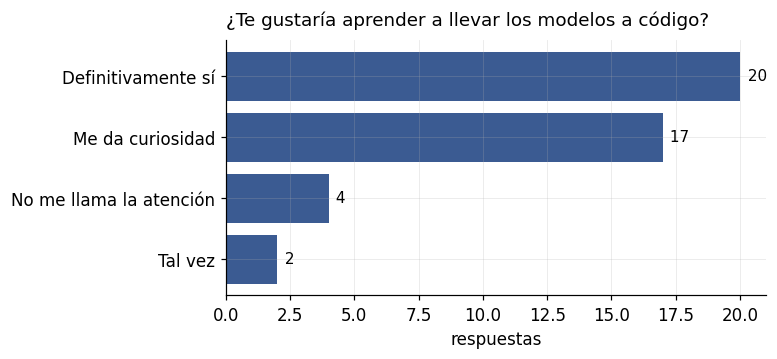

Interesados (definitivamente + curiosidad): 37/43 = 86%


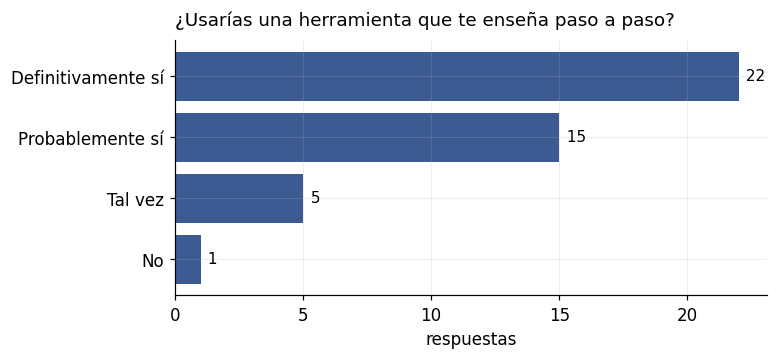

Usarían (definitivamente + probablemente): 37/43 = 86%


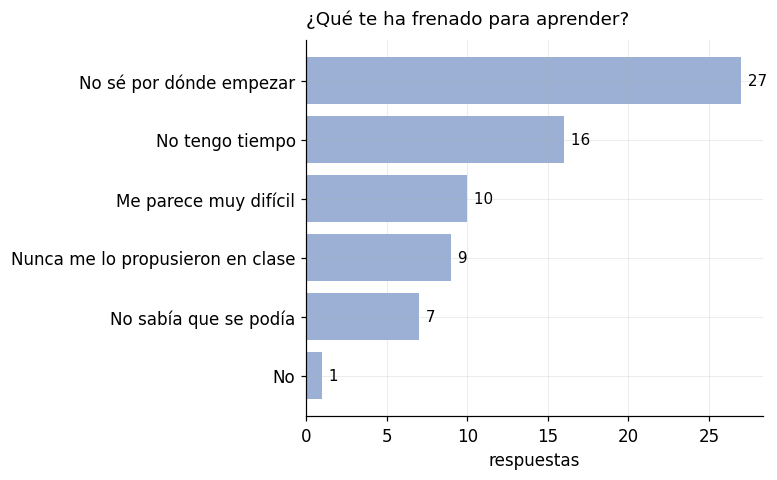

In [11]:
nu = df[df.nu_interes.notna()].copy()
print("Segmento no-usuarios que respondió:", len(nu))

# Interés en aprender a llevar modelos a código
orden_i = ["Definitivamente sí","Me da curiosidad","Tal vez","No me llama la atención"]
ii = nu.nu_interes.value_counts().reindex(orden_i).dropna()
hbar(ii, "¿Te gustaría aprender a llevar los modelos a código?", "demanda_interes")

interes_pos = nu.nu_interes.isin(["Definitivamente sí","Me da curiosidad"]).sum()
print(f"Interesados (definitivamente + curiosidad): {interes_pos}/{len(nu)} = {interes_pos/len(nu):.0%}")

# ¿Usarían una herramienta que les enseña?
orden_u = ["Definitivamente sí","Probablemente sí","Tal vez","No"]
uu = nu.nu_usaria.value_counts().reindex(orden_u).dropna()
hbar(uu, "¿Usarías una herramienta que te enseña paso a paso?", "demanda_usaria")
usaria_pos = nu.nu_usaria.isin(["Definitivamente sí","Probablemente sí"]).sum()
print(f"Usarían (definitivamente + probablemente): {usaria_pos}/{len(nu)} = {usaria_pos/len(nu):.0%}")

# Barreras
hbar(multiselect_counts(nu.nu_barreras), "¿Qué te ha frenado para aprender?",
     "demanda_barreras", color=ACCENT2)


## 6. Disposición a pagar (limitación)

Por el fallo de ruteo, el bloque de uso/pago del segmento *con experiencia* solo
capturó **1 respuesta**, insuficiente para concluir. La señal de demanda válida es
la del segmento no-usuarios (sección 5). **Fix v2:** mover la pregunta de
disposición a pagar a una página común al final, fuera de la rama condicional.

In [12]:
print("Usuarios — ¿usarían el traductor? (n insuficiente):")
print(df.u_usaria.value_counts(dropna=True).to_string() or "(sin datos)")
print("\nUsuarios — ¿pagarían? (n insuficiente):")
print(df.u_pagaria.value_counts(dropna=True).to_string() or "(sin datos)")


Usuarios — ¿usarían el traductor? (n insuficiente):
u_usaria
No    1

Usuarios — ¿pagarían? (n insuficiente):
u_pagaria
No pagaría    1


## 7. Hallazgos clave (para el pitch)

In [13]:
# Cifras citables, calculadas en vivo
n = len(df)
nunca = int((df.nivel == "Nunca lo he usado").sum())
fr_mean = round(pd.to_numeric(df[df.replicar.notna()].frustracion, errors='coerce').mean(),2)
ia_n = int(df.ia_freq.notna().sum())
ia_err = int(df.ia_freq.isin(["Siempre","Casi siempre","A veces"]).sum())
no_verif = int(df.ia_catch.str.startswith("No", na=False).sum()
               + df.ia_catch.str.contains("con ayuda", na=False).sum())
nu = df[df.nu_interes.notna()]
interes_pos = int(nu.nu_interes.isin(["Definitivamente sí","Me da curiosidad"]).sum())
usaria_pos = int(nu.nu_usaria.isin(["Definitivamente sí","Probablemente sí"]).sum())

hallazgos = f'''# Hallazgos clave — Encuesta de validación (n={n})

- **{nunca}/{n} ({nunca/n:.0%}) nunca han usado Dynare**, pese a ser estudiantes
  de macroeconomía. El problema de acceso es tan grande que la mayoría ni lo intenta.
- Entre quienes lo intentaron, la **frustración media es {fr_mean}/5**.
- De los {ia_n} que usaron IA para Dynare, **{ia_err} recibieron código con errores**
  ("a veces" o más seguido), y **{no_verif}/{ia_n} ({no_verif/ia_n:.0%}) no pudieron
  verificar solos** si el código estaba bien (lo usaron a ciegas o necesitaron ayuda).
  → Este es el *why now*: la IA genérica se equivoca y el alumno no se da cuenta.
- Demanda latente (no-usuarios, n={len(nu)}):
  **{interes_pos}/{len(nu)} ({interes_pos/len(nu):.0%}) quieren aprender** a llevar
  sus modelos a código, y **{usaria_pos}/{len(nu)} ({usaria_pos/len(nu):.0%}) usarían**
  una herramienta que les enseñe paso a paso.

_Limitación: disposición a pagar del segmento con experiencia no medible (ruteo, n=1)._
'''
Path("HALLAZGOS.md").write_text(hallazgos, encoding="utf-8")
print(hallazgos)


# Hallazgos clave — Encuesta de validación (n=59)

- **42/59 (71%) nunca han usado Dynare**, pese a ser estudiantes
  de macroeconomía. El problema de acceso es tan grande que la mayoría ni lo intenta.
- Entre quienes lo intentaron, la **frustración media es 3.47/5**.
- De los 14 que usaron IA para Dynare, **11 recibieron código con errores**
  ("a veces" o más seguido), y **9/14 (64%) no pudieron
  verificar solos** si el código estaba bien (lo usaron a ciegas o necesitaron ayuda).
  → Este es el *why now*: la IA genérica se equivoca y el alumno no se da cuenta.
- Demanda latente (no-usuarios, n=43):
  **37/43 (86%) quieren aprender** a llevar
  sus modelos a código, y **37/43 (86%) usarían**
  una herramienta que les enseñe paso a paso.

_Limitación: disposición a pagar del segmento con experiencia no medible (ruteo, n=1)._

